# MBHB single-source likelihood tutorial

This notebook walks through the full pipeline for evaluating the LISA
likelihood of a single **massive black-hole binary (MBHB)** source, from the raw
L1 time-domain data down to a signal-likelihood / SNR / mismatch cross-check
against the injected source.

The high-level steps are:

1. **Configuration** — logging, data paths, the analysis domain (FD or STFT),
   the frequency band, and the waveform settings.
2. **Data loading & preprocessing** — read source 18 from the L1 dataset,
   filter / downsample / trim it, and pour it into a `DataResidualArray`.
3. **Noise model** — build the `XYZ` sensitivity matrix used in the inner product.
4. **Analysis containers** — replicate the data into a small batch to exercise
   the batched (multi-template / multi-temperature) likelihood machinery.
5. **Likelihood evaluations** — first the PSD (noise) likelihood, then the MBHB
   signal likelihood, and finally a single-template SNR / mismatch check.

> JAX is configured for `float64` precision on the **CPU** backend (see the
> first code cell). Switch `BACKEND` / `jax_platform_name` to run on GPU.


In [ ]:
import logging
import sys
import os 
from copy import deepcopy
import time


import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

import jax.numpy as jnp
import h5py
import numpy as np

from lisatools.detector import L1Orbits
from lisatools.globalfit.preprocessing import L1ProcessingStep
from lisatools.sources.bbh.waveform import PhenomTHMTDIWaveform
from lisatools.analysiscontainer import AnalysisContainer, AnalysisContainerArray
from lisatools.domains import get_stft_settings, FDSettings, TDSettings
from lisatools.domaincomputation import DomainComputationGroupArray
from lisatools.utils.constants import YRSID_SI
from lisatools.utils.utility import tukey
from lisatools.sensitivity import XYZSensitivityBackend
from lisatools.datacontainer import DataResidualArray

from tqdm import tqdm

import matplotlib.pyplot as plt

No CuPy


## 1. Configuration

The next cells set up logging and define the run configuration:

- **paths** — where the L1 data lives and where outputs are written;
- **`DOMAIN` / frequency band** — whether the likelihood is computed in the
  frequency domain (`"fd"`) or the short-time Fourier domain (`"stft"`), and the
  `[FREQ_MIN, FREQ_MAX]` band that is kept;
- **`NUM_ACS` / `NUM_TEMP`** — the batch dimensions (number of analysis
  containers and temperatures) used to drive the batched likelihood;
- **`wave_kwargs`** — the higher modes and integration tolerances passed to the
  PhenomT waveform model.

`get_domain_settings` is a helper returning the appropriate domain-settings
object (`FDSettings` or STFT settings) plus the segment length `nperseg`, which
is later used to size the Tukey window.


In [2]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)

In [3]:
path = "/Volumes/as_storage/mojito/mojito_light_2p5s" # path to the data folder
savedir = "./tutorial_output/"
os.makedirs(savedir, exist_ok=True)

In [4]:
FIGSIZE = (10, 6)
BACKEND = "cpu"
print(f"Using {BACKEND} backend")

def get(x):
    return x.get() if hasattr(x, 'get') else x

Using cpu backend


In [5]:
DOMAIN = "fd"
STFT_DT = 24 * 3600 if DOMAIN == "stft" else None
FREQ_MAX = 2.9e-2
FREQ_MIN = 1e-4

TAPER_LENGTH = 1 / FREQ_MIN # seconds

# our source of batching
NUM_ACS = 5
NUM_TEMP = 1

In [ ]:
tol = 1e-12
hms = [21, 33, 44]

Tobs = YRSID_SI / 12.  # 1 month
wave_kwargs = dict(
        higher_modes=hms,
        include_negative_modes=True, # negative m modes will be produced by simmetry
        coarse_grain = False,
        t_low_fit=True,
        atol=tol,
        rtol=tol,
    )

In [22]:
def get_domain_settings(times: np.ndarray) -> tuple: 
    """
    Get the settings in the desired domain (STFT or FD) for the likelihood computation. 

    Args:
        times (np.ndarray): The time array of the data.
    
    Returns:
        Domain settings object (STFTSettings or FDSettings) based on the specified DOMAIN.
        nperseg (int): Number of points per time segment. Used to determine the window parameter.
    """
    if DOMAIN == "stft":
        settings = get_stft_settings(
            times=times,
            big_dt=STFT_DT,
            min_freq=FREQ_MIN,
            max_freq=FREQ_MAX,
        )

        nperseg = settings.get_nperseg(times[1] - times[0])
    
    elif DOMAIN == "fd":
        Nt = len(times)
        dt = times[1] - times[0]
        N = Nt // 2 + 1  # Number of positive frequency bins
        df = 1 / (Nt * dt)
        settings = FDSettings(
            df=df,
            N=N,
            min_freq=FREQ_MIN,
            max_freq=FREQ_MAX
        )
        nperseg = len(times)  # For FD, nperseg is the length of the time array

    return settings, nperseg

## 2. Data loading and preprocessing

`L1ProcessingStep` loads the requested source (here a single MBHB, source ID 18)
from the L1 dataset and exposes its catalogue parameters and orbits.

`loader.process(...)` then runs the preprocessing pipeline — highpass + lowpass
filtering, downsampling to `target_fs`, and trimming from each end / down to
`Tobs` — and returns the (downsampled) time array. From that we build the
analysis-domain settings and the Tukey window, and `loader.pour(...)` projects
the data into a `DataResidualArray` together with the orbit information. The
final cell plots the resulting data.


In [23]:
source_types = [
    'mbhb', 
    ]

SOURCE_ID = 18

source_ids = dict(
    mbhb = [SOURCE_ID]
)

loader = L1ProcessingStep(
    L1_folder=path,
    source_types=source_types,
    source_ids=source_ids,
    orbits_class=L1Orbits,
    orbits_kwargs=dict(force_backend=BACKEND, frame="icrs"),
    verbose=True,
    do_plots=False
)
downsample_kwargs = {
    "target_fs": 0.2,  # Hz — target sampling rate (None = no downsampling).
    "window": ("kaiser", 31.0)  # Kaiser window beta parameter (higher = more aggressive anti-aliasing)
}

default_preprocess_kwargs = dict(
        highpass_kwargs=dict(cutoff=1e-5, order=2, zero_phase=True),
        lowpass_kwargs=dict(cutoff=0.8 * downsample_kwargs['target_fs'], order=2, zero_phase=True),
        trim_kwargs=dict(
            duration=200 * 3600, is_percent=False, trimming_type="from_each_end"
        ),
        downsample_kwargs=downsample_kwargs,
        Tobs=5. * YRSID_SI / 12.0 #YRSID_SI / 12 * 7,
    )

2026-06-27 16:19:14,401 - lisatools.globalfit.preprocessing - INFO - L1DataLoader initialized with data folder: /Volumes/as_storage/mojito/mojito_light_2p5s/data
2026-06-27 16:19:14,402 - lisatools.globalfit.preprocessing - INFO - Source types to load: ['MBHB']
2026-06-27 16:19:14,402 - lisatools.globalfit.preprocessing - INFO - Source IDs: {'MBHB': [18]}
2026-06-27 16:19:14,403 - lisatools.globalfit.preprocessing - INFO - Orbits class: L1Orbits
2026-06-27 16:19:14,403 - lisatools.globalfit.preprocessing - INFO - Orbits kwargs: {'force_backend': 'cpu', 'frame': 'icrs'}
2026-06-27 16:19:14,403 - lisatools.globalfit.preprocessing - INFO - Loading data for source type 'MBHB'
Loading MBHB sources:   0%|          | 0/1 [00:00<?, ?it/s]2026-06-27 16:19:14,411 - lisatools.globalfit.preprocessing - INFO - Loaded catalogue parameters for MBHB source ID 18 from catalogue.


[load_data] MBHB source 18 f.tdis.xyz_doppler[:] took 1.03s shape=(25246480, 3)


2026-06-27 16:19:19,822 - lisatools.globalfit.preprocessing - INFO - Initialized orbits from MBHB file.
Loading MBHB sources: 100%|██████████| 1/1 [00:05<00:00,  5.42s/it]


In [24]:
times, _ = loader.process(**default_preprocess_kwargs)
dt = loader.td_signal.settings.dt
td_settings = TDSettings(*loader.td_signal.settings.args, force_backend=BACKEND)

2026-06-27 16:19:19,836 - lisatools.globalfit.preprocessing - INFO - Applying highpass filter...
2026-06-27 16:19:22,911 - lisatools.globalfit.preprocessing - INFO - Applying lowpass filter...
2026-06-27 16:19:24,194 - lisatools.globalfit.preprocessing - INFO - Downsampling data...
2026-06-27 16:19:25,587 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=12623240, T=63116195.000000015
2026-06-27 16:19:25,587 - lisatools.globalfit.preprocessing - INFO - Trimming data...
2026-06-27 16:19:25,587 - lisatools.globalfit.preprocessing - INFO - Trimming 720000s (144000 samples) from each end of the data.
2026-06-27 16:19:25,588 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=12335240, T=61676195.000000015
2026-06-27 16:19:25,588 - lisatools.globalfit.preprocessing - INFO - Keeping first 13149229.068144s (2629845 samples) of the data.
2026-06-27 16:19:25,588 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=2629845, T=13149220.0


In [25]:
settings, nperseg = get_domain_settings(times)
tukey_alpha = TAPER_LENGTH / (nperseg * dt)  # Calculate the Tukey alpha based on the taper length and segment length

window = tukey(nperseg, tukey_alpha)

In [26]:
binary_params = loader.catalogue['MBHB'][source_ids['mbhb'][0]]
input_data_residual_array, orbits = loader.pour(
            settings=settings, window=window, return_orbits=True
        )
xp = orbits.xp

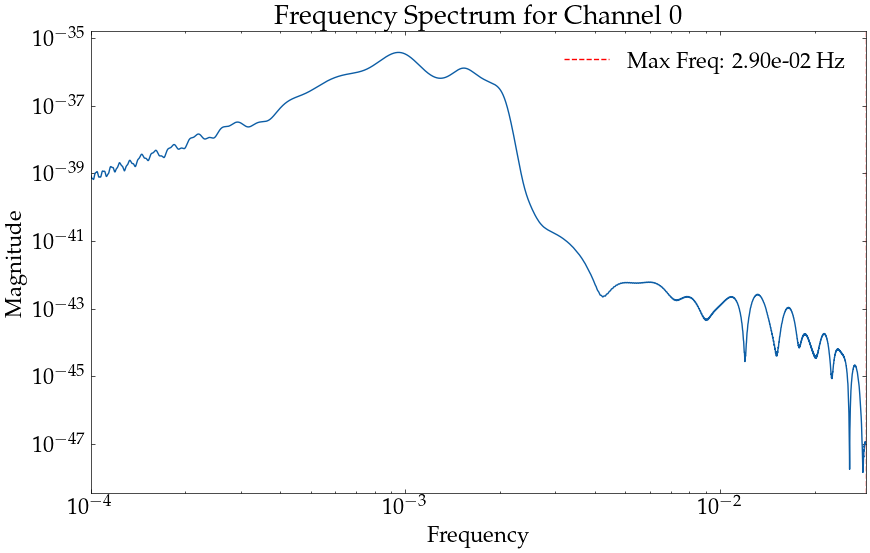

In [ ]:
# visualize the data in the target domain (STFT or FD)

ax = input_data_residual_array.data_res_arr.plot(filename=f"{savedir}data.png")

## 3. Noise model — sensitivity matrix

`XYZSensitivityBackend` builds the cross-channel (X, Y, Z) sensitivity / noise
covariance matrix that enters the likelihood inner product. It is parametrised
by the optical-metrology noise (`Soms`) and the acceleration noise (`Sa`);
`set_sensitivity_matrix` evaluates the matrix for the chosen frequency band and
TDI generation.


In [29]:
sensitivity_backend = XYZSensitivityBackend(
        orbits=orbits,
        settings=settings,
        force_backend=BACKEND,
        tdi_generation=2,
        mask_percentage=0.02,
        window_values=window
    )
logger.info("Sensitivity backend initialized.")

Soms = 15e-12
Sa =  3e-15

sensitivity_backend.set_sensitivity_matrix(Soms, Sa)

logger.info("Sensitivity matrix computed.")

2026-06-27 16:19:49,691 - __main__ - INFO - Sensitivity backend initialized.
2026-06-27 16:19:49,945 - __main__ - INFO - Sensitivity matrix computed.


## 4. Analysis containers and computation groups

An `AnalysisContainer` bundles one copy of the data residual array with its
sensitivity matrix. We deep-copy it `NUM_ACS` times and wrap the copies in an
`AnalysisContainerArray`; the `DomainComputationGroupArray` (`dcga`) is the
object that actually dispatches batched likelihood / waveform computations
across these containers (and across GPUs, when available).

Replicating identical data is simply a convenient way to drive the batched
machinery in this tutorial — in a real run each container would hold different
data / templates.


In [30]:
ac_list = []
for i in tqdm(range(NUM_ACS), desc="Creating analysis containers"):
    ac = AnalysisContainer(
        data_res_arr=deepcopy(input_data_residual_array),
        sens_mat=deepcopy(sensitivity_backend)
    ) 
    ac_list.append(ac)

ac_array = AnalysisContainerArray(ac_list, gpus=None)
logger.info("Analysis container array created.")

dcga = DomainComputationGroupArray(
    acs=ac_array
)   

logger.info("Domain computation group array created.")

Creating analysis containers: 100%|██████████| 5/5 [00:00<00:00, 18.74it/s]


2026-06-27 16:19:50,345 - __main__ - INFO - Analysis container array created.
2026-06-27 16:19:56,479 - __main__ - INFO - Domain computation group array created.


## 5. Likelihood evaluations

With the data, noise model, and computation groups in place, we can evaluate
likelihoods. Two distinct paths are exercised below:

- the **PSD (noise) likelihood**, which depends only on the noise parameters; and
- the **MBHB signal likelihood**, which generates a waveform template and
  compares it to the data.


### PSD (noise) likelihood

This evaluates the likelihood of the noise model alone. We pack the noise
parameters (`Soms`, `Sa`) and a dummy galactic-foreground array into per-source
coordinate arrays, map each batch element to a data container via
`unpack_indices` / `unpack_coords`, and move everything onto the compute device.

`compute_psd_likelihood` then evaluates the batch; the loop below repeats it a
few times to report an average wall-clock time per evaluation. (`unpack` just
reshapes the coordinates into the argument layout the likelihood expects.)


In [31]:
def unpack(x, y): 
    return (x[:, 0], x[:, 1], *y.T)

In [32]:
Soms = np.full((NUM_ACS * NUM_TEMP,), Soms)
Sa = np.full((NUM_ACS * NUM_TEMP,), Sa)
psd_pars = np.array([Soms, Sa]).T # dummy psd pars for now, not used in the likelihood computation
galfor_pars = np.zeros((NUM_ACS * NUM_TEMP, 5)) # dummy galfor array for now, not used in the likelihood computation

data_index_all = np.arange(NUM_ACS * NUM_TEMP, dtype=np.int32) % NUM_ACS

positions_per_split, data_intra_index_per_split, _ = dcga.unpack_indices(data_index_all)
coords_per_split = dcga.unpack_coords(positions_per_split, (psd_pars, galfor_pars))

data_intra_index_per_split, coords_per_split = dcga.place_on_device(
    items=(data_intra_index_per_split, coords_per_split)
)


In [33]:
run_threaded = False
run_async = True

likelihood_args_per_split = dcga._loop_operation(operation=unpack, operation_args_per_split=coords_per_split,)

like = dcga.compute_psd_likelihood(positions_per_split, data_intra_index_per_split, data_intra_index_per_split, likelihood_args_per_split, likelihood_kwargs={'run_async': run_async}, run_threaded=run_threaded,)

num_tries = 5

tic = time.time()
for _ in tqdm(range(num_tries), desc="Testing likelihood computation"):
    like = dcga.compute_psd_likelihood(positions_per_split, data_intra_index_per_split, data_intra_index_per_split, likelihood_args_per_split, likelihood_kwargs={'run_async': run_async}, run_threaded=run_threaded,)
toc = time.time()
logger.info(f"Average time per likelihood computation: {(toc - tic) / num_tries:.3f} seconds")

Testing likelihood computation: 100%|██████████| 5/5 [00:03<00:00,  1.56it/s]

2026-06-27 16:20:00,526 - __main__ - INFO - Average time per likelihood computation: 0.640 seconds


### MBHB (signal) likelihood

Now the signal likelihood. The steps are:

1. read the injected binary parameters for source 18 from the catalogue;
2. broadcast them into `(NUM_ACS * NUM_TEMP, n_params)` coordinate arrays
   (`full_arr`) — every batch element uses the true parameters here;
3. build a `PhenomTHMTDIWaveform` generator (plus one replica per device); and
4. generate templates and feed them through `compute_signal_likelihood`.


In [34]:
m1 = float(binary_params['PrimaryMassSSBFrame'][()].squeeze())
m2 = float(binary_params['SecondaryMassSSBFrame'][()].squeeze())
s1z = float(binary_params['PrimarySpinCompZ'][()].squeeze())
s2z = float(binary_params['SecondarySpinCompZ'][()].squeeze())
distance = float(binary_params['LuminosityDistance'][()].squeeze())
redshift = float(binary_params['Redshift'][()].squeeze())
inclination = float(binary_params['InclinationAngle'][()].squeeze())
phi_ref = float(binary_params['PhaseReferenceSourceFrame'][()].squeeze()) % (2 * np.pi)
f22_start =  float(binary_params['GW22FrequencySSBFrame'][()].squeeze())
f22_ref =  float(binary_params['GW22FrequencySSBFrame'][()].squeeze())
ra = float(binary_params['RightAscension'][()].squeeze())
dec = float(binary_params['Declination'][()].squeeze())
psi = float(binary_params['PolarisationAngle'][()].squeeze())
snr = float(binary_params['EstimatedSNR'][()].squeeze())
tmerg = float(binary_params['TimeCoalescencePhenomTPHMSSBFrame'][()].squeeze())
t0 = float(binary_params["TimeReferenceSSBFrame"][()].squeeze())

logger.info(f"Loaded binary parameters for source ID {SOURCE_ID}:")
logger.info(f"m1: {m1} Msun")
logger.info(f"m2: {m2} Msun")
logger.info(f"s1z: {s1z}")
logger.info(f"s2z: {s2z}")
logger.info(f"distance: {distance} Mpc")
logger.info(f"redshift: {redshift}")
logger.info(f"inclination: {inclination} rad")
logger.info(f"phi_ref: {phi_ref} rad")
logger.info(f"f22_start: {f22_start} Hz")
logger.info(f"f22_ref: {f22_ref} Hz")
logger.info(f"ra: {ra} rad")
logger.info(f"dec: {dec} rad") 
logger.info(f"psi: {psi} rad")
logger.info(f"snr: {snr}")
logger.info(f"tmerg: {tmerg} s")
logger.info(f"t0: {t0} s")

2026-06-27 16:20:00,531 - __main__ - INFO - Loaded binary parameters for source ID 18:
2026-06-27 16:20:00,532 - __main__ - INFO - m1: 11819689.7322 Msun
2026-06-27 16:20:00,532 - __main__ - INFO - m2: 5405225.836920001 Msun
2026-06-27 16:20:00,532 - __main__ - INFO - s1z: -0.1278766201232866
2026-06-27 16:20:00,533 - __main__ - INFO - s2z: 0.5007290688254868
2026-06-27 16:20:00,533 - __main__ - INFO - distance: 61128.74112902759 Mpc
2026-06-27 16:20:00,533 - __main__ - INFO - redshift: 6.18186
2026-06-27 16:20:00,533 - __main__ - INFO - inclination: 2.267026728679152 rad
2026-06-27 16:20:00,534 - __main__ - INFO - phi_ref: 0.8175850132930255 rad
2026-06-27 16:20:00,534 - __main__ - INFO - f22_start: 2.0886886878886526e-05 Hz
2026-06-27 16:20:00,534 - __main__ - INFO - f22_ref: 2.0886886878886526e-05 Hz
2026-06-27 16:20:00,534 - __main__ - INFO - ra: 4.016646424125452 rad
2026-06-27 16:20:00,535 - __main__ - INFO - dec: -0.3433144952663676 rad
2026-06-27 16:20:00,535 - __main__ - INFO 

In [35]:
m1_arr = np.full((NUM_ACS * NUM_TEMP,), m1)
m2_arr = np.full((NUM_ACS * NUM_TEMP,), m2)
s1z_arr = np.full((NUM_ACS * NUM_TEMP,), s1z)
s2z_arr = np.full((NUM_ACS * NUM_TEMP,), s2z)
distance_arr = np.full((NUM_ACS * NUM_TEMP,), distance)
inclination_arr = np.full((NUM_ACS * NUM_TEMP,), inclination)
phi_ref_arr = np.full((NUM_ACS * NUM_TEMP,), phi_ref)
ra_arr = np.full((NUM_ACS * NUM_TEMP,), ra)
dec_arr = np.full((NUM_ACS * NUM_TEMP,), dec)
psi_arr = np.full((NUM_ACS * NUM_TEMP,), psi)
tmerg_arr = np.full((NUM_ACS * NUM_TEMP,), tmerg)

full_arr = np.array([m1_arr, m2_arr, s1z_arr, s2z_arr, distance_arr, phi_ref_arr, inclination_arr, psi_arr, ra_arr, dec_arr, tmerg_arr]).T

logger.info("Binary parameters loaded.")
logger.info(f"Array shape: {full_arr.shape}")

2026-06-27 16:20:00,541 - __main__ - INFO - Binary parameters loaded.
2026-06-27 16:20:00,541 - __main__ - INFO - Array shape: (5, 11)


#### Building the waveform generator

`PhenomTHMTDIWaveform` produces the TDI (X, Y, Z) response of the
phenomenological time-domain higher-mode waveform, on the same time grid and
frequency band as the data.

The helper functions below adapt it to the batched, multi-device machinery:

- `make_args_tuple` — splits the coordinate matrix into per-parameter arrays,
  forcing a fresh, 16-byte-aligned allocation per column (XLA rejects misaligned
  DLPack buffers);
- `prepare_inputs` — unpacks indices / coords and builds the per-split waveform
  arguments;
- `create_waveform_gen_replicas` — makes one generator per device, each bound to
  that device's orbits.


In [36]:
wave_gen = PhenomTHMTDIWaveform(
        waveform_kwargs=wave_kwargs,
        Tobs=Tobs,              # must be in years
        start_freq=7e-5,
        use_reference_time=True,
        waveform_t0=t0,
        data_td_settings=td_settings,
        sampling_frequency=1.0 / dt,
        orbits=orbits,
        tdi_channels="XYZ",
        tdi_generation="2nd generation",
        order=30,
        force_backend=BACKEND,
        tukey_alpha=tukey_alpha,
        buffer_time=10000,
        stft_dt=STFT_DT,
        freq_min=FREQ_MIN,
        freq_max=FREQ_MAX,
        run_async=run_async
    )

logger.info("Waveform generator initialized.")

2026-06-27 16:20:08,666 - __main__ - INFO - Waveform generator initialized.


In [37]:
def make_args_tuple(coords) -> tuple:
    """
    Make a tuple of arguments for the waveform generator from the given coordinates.
    """
    # cp.array() forces a fresh allocation for each column.
    # unpack_coords produces Fortran-order arrays, so coords[:, i] is an
    # already-contiguous column view — ascontiguousarray would return the same
    # pointer (base + i*N*itemsize).  When N*itemsize % 16 != 0, that pointer
    # is misaligned and XLA rejects it via DLPack.  cp.array() always copies.
    return tuple(xp.array(coords[:, i]) for i in range(coords.shape[1]))

def prepare_inputs(dcga, coords, data_index):
    """
    Prepare the inputs for the waveform generator from the given coordinates and data index.
    """

    positions_per_split, data_intra_index_per_split, _ = dcga.unpack_indices(data_index)
    coords_per_split = dcga.unpack_coords(positions_per_split, coords, keep_tuple=True)

    data_intra_index_per_split, coords_per_split = dcga.place_on_device(
        items=(data_intra_index_per_split, coords_per_split)
    )

    waveform_args_per_split = dcga._loop_operation(
        operation=[make_args_tuple for _ in dcga.computation_groups],
        operation_args_per_split=coords_per_split,
    )

    return positions_per_split, data_intra_index_per_split, waveform_args_per_split

def create_waveform_gen_replicas(dcga, waveform_gen):
    """
    Create replicas of the waveform generator for each GPU.
    """

    _waveform_generators = []
    for i, device in enumerate(
        dcga.gpus if dcga.gpus is not None else [None] * dcga.num_splits
    ):
        if not hasattr(waveform_gen, "kwargs"):
            raise ValueError("Waveform generator must have a 'kwargs' attribute that contains the keyword arguments to initialize the waveform generator.")    
        
        with dcga.device_context(device):
            init_kwargs = waveform_gen.kwargs.copy()
            if "orbits" in init_kwargs:
                init_kwargs["orbits"] = dcga.computation_groups[i].orbits

            _waveform_generators.append(
                waveform_gen.__class__(**init_kwargs)
            )

    return _waveform_generators

In [38]:
data_index = np.arange(m1_arr.shape[0]) % len(ac_array)

waveform_generators = create_waveform_gen_replicas(dcga, wave_gen)
logger.info("Waveform generator replicas created.")

waveform_like_operations = [wf.__call__ for wf in waveform_generators]

2026-06-27 16:20:12,577 - __main__ - INFO - Waveform generator replicas created.


In [39]:
logger.info(f"waveform_generators is a list of {len(waveform_generators)} replicas.") 

2026-06-27 16:20:12,590 - __main__ - INFO - waveform_generators is a list of 1 replicas.


#### Computing the signal likelihood

The first `_loop_operation` call is an untimed **warm-up** — JIT compilation and
buffer allocation happen here. The timed block then regenerates the templates
and runs `compute_signal_likelihood` over the whole batch, reporting the average
time per likelihood evaluation. Because every batch element uses identical
parameters, the returned likelihoods are all equal.


In [47]:
positions_per_split, data_intra_index_per_split, waveform_args_per_split = prepare_inputs(dcga, full_arr, data_index)

run_threaded = False

_ = dcga._loop_operation(operation=waveform_like_operations, operation_args_per_split=waveform_args_per_split, positions_per_split=positions_per_split, run_threaded=run_threaded,) 

In [48]:
print("Warmup done, starting timed runs...")
print("running with threading:", run_threaded)
print("running with async:", waveform_generators[0].run_async)

tic = time.time()
likelihood_args_per_split = dcga._loop_operation(operation=waveform_like_operations, operation_args_per_split=waveform_args_per_split, positions_per_split=positions_per_split, run_threaded=run_threaded,)
likelihoods = dcga.compute_signal_likelihood(positions_per_split=positions_per_split, data_intra_per_split=data_intra_index_per_split, noise_intra_per_split=data_intra_index_per_split, likelihood_args_per_split=likelihood_args_per_split, likelihood_kwargs={'run_async': waveform_generators[0].run_async}, run_threaded=run_threaded,)
print("Time elapsed:", time.time() - tic)
print("Average time per likelihood computation: ", (time.time() - tic) / (NUM_ACS * NUM_TEMP))

print("Likelihoods computed:", likelihoods)

Warmup done, starting timed runs...
running with threading: False
running with async: True
Time elapsed: 3.5483510494232178
Average time per likelihood computation:  0.7097815990447998
Likelihoods computed: [-227.61878519 -227.61878519 -227.61878519 -227.61878519 -227.61878519]


#### Cross-check: single-template SNR and mismatch

As a sanity check we generate the template for the first batch element on its
own, wrap it in a `DataResidualArray`, and compute its likelihood directly — it
should match the batched value above. We then compute the optimal vs. detected
SNR and the mismatch between template and data.


In [49]:
template = waveform_generators[0].get_signals_for_residuals(*full_arr[0])


In [50]:
template = DataResidualArray(template)
ac_list[0].template_likelihood(template)

np.float64(-227.61878407001495)

In [51]:
opt_snr, det_snr = ac_list[0].template_snr(template)

mismatch = 1 - (ac_list[0].template_inner_product(template) / (opt_snr * np.sqrt(ac_list[0].inner_product())))
print("Optimal SNR:", opt_snr)
print("Detected SNR:", det_snr)
print("Mismatch:", mismatch)

Optimal SNR: 773.9834621588477
Detected SNR: 773.6881816067965
Mismatch: 0.0003799665843905453


#### Caveats

##### Caveat 1
The mismatch reported just above is dominated by the specifics of the LISA
response function implemented in **this** tutorial. In our main development
environment the response has been fixed, and the same source recovers a
near-zero mismatch.

For reference, the values obtained there — with both the *Lagrangian* and
*quintic* interpolation schemes for the response — are:

| Source ID | Response scheme | Data SNR | Template optimal SNR | Template detected SNR | Residual SNR | Mismatch    |
| :-------: | :-------------- | :------: | :------------------: | :-------------------: | :----------: | :---------- |
| 18        | Lagrangian      | 773.619  | 773.603              | 773.619               | 0.997        | 8.30655e-07 |
| 18        | quintic         | 773.619  | 773.603              | 773.619               | 0.996        | 8.28051e-07 |


##### Caveat 2
The aforementioned environment incorporates a list of changes to our codebase that make this tutorial slightly out of date.
Since we are still in the process of ensuring the correctness of these changes, we did not want to include them in this tutorial yet. The main differences are:
- the `fastlisaresponse` package has been retired and absorbed into `lisatools`. There, we are adding a quintic interpolation scheme for the projections, alongside the existing lagrangian one. The tutorial still uses the lagrangian scheme.
- The `DataResidualArray` class has been deprecated in favor of the direct usage of the `DomainBase` subclasses. The tutorial still uses the `DataResidualArray` class.
- The `DomainComputationGroupArray` logic is being absorbed directly into the `AnalysisContainerArray` class. The tutorial still uses the `DomainComputationGroupArray` class.
- some more minor tweaks overall.

##### Caveat 3
The `ComputationGroupArray` route was not necessary for this tutorial, or to get timings on a single GPU. It is only used here to demonstrate the full multi-device machinery. The [`MultiGPU`] version of our proposals already take care of the multi-device dispatching internally, and the user does not need to worry about it.